# Time Series Sales Forecasting with ARIMA and Prophet

This notebook demonstrates:
1. Loading and exploring the local sales dataset
2. Data preprocessing and exploration
3. Time series forecasting using ARIMA
4. Time series forecasting using Prophet
5. Model evaluation and comparison

## 1. Setup and Imports

In [1]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Statistical tests
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# Prophet
from prophet import Prophet

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")

Importing plotly failed. Interactive plots will not work.


All libraries imported successfully!


## 2. Load Local Dataset

In [2]:
# Load the local sales dataset
df = pd.read_csv('store_sales.csv', parse_dates=['date'])

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate Range: {df['date'].min()} to {df['date'].max()}")
print(f"\nNumber of Stores: {df['store'].nunique()}")
print(f"\nData Types:")
print(df.dtypes)
df.head(10)

Dataset Shape: (7300, 5)

Columns: ['date', 'store', 'sales', 'promo', 'holiday']

Date Range: 2022-01-01 00:00:00 to 2023-12-31 00:00:00

Number of Stores: 10

Data Types:
date       datetime64[ns]
store               int64
sales             float64
promo               int64
holiday             int64
dtype: object


,date,store,sales,promo,holiday
0,2022-01-01,1,184.78,0,0
1,2022-01-02,1,192.62,0,0
2,2022-01-03,1,212.68,0,0
3,2022-01-04,1,249.58,1,0
4,2022-01-05,1,223.50,0,0
5,2022-01-06,1,221.79,0,0
6,2022-01-07,1,200.43,0,0
7,2022-01-08,1,213.47,1,0
8,2022-01-09,1,222.44,1,0
9,2022-01-10,1,203.10,0,0


In [3]:
# Basic statistics
print("Dataset Statistics:")
df.describe()

Dataset Statistics:


,date,store,sales,promo,holiday
count,7300,7300.000000,7300.000000,7300.000000,7300.000000
mean,2022-12-31 12:00:00,5.500000,228.434571,0.202192,0.104110
min,2022-01-01 00:00:00,1.000000,160.710000,0.000000,0.000000
25%,2022-07-02 00:00:00,3.000000,209.217500,0.000000,0.000000
50%,2022-12-31 12:00:00,5.500000,226.795000,0.000000,0.000000
75%,2023-07-02 00:00:00,8.000000,245.590000,0.000000,0.000000
max,2023-12-31 00:00:00,10.000000,340.730000,1.000000,1.000000
std,NaN,2.872478,26.625636,0.401662,0.305424


## 3. Data Preprocessing

In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal Missing: {df.isnull().sum().sum()}")

Missing Values:
date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64

Total Missing: 0


In [5]:
# Aggregate sales by date (total daily sales across all stores)
daily_sales = df.groupby('date').agg({
    'sales': 'sum',
    'promo': 'sum',
    'holiday': 'max'
}).reset_index()

daily_sales.columns = ['date', 'total_sales', 'promo_count', 'is_holiday']
daily_sales = daily_sales.set_index('date')

print(f"Daily Sales Shape: {daily_sales.shape}")
print(f"\nStatistics:")
print(daily_sales.describe())

daily_sales.head(10)

Daily Sales Shape: (730, 3)

Statistics:
       total_sales  promo_count  is_holiday
count   730.000000   730.000000  730.000000
mean   2284.345712     2.021918    0.672603
std     183.525986     1.301919    0.469585
min    1884.290000     0.000000    0.000000
25%    2145.850000     1.000000    0.000000
50%    2278.430000     2.000000    1.000000
75%    2420.315000     3.000000    1.000000
max    2826.120000     7.000000    1.000000


,total_sales,promo_count,is_holiday
date,,,
2022-01-01,1947.47,3,1
2022-01-02,1942.29,2,0
2022-01-03,2099.73,2,1
2022-01-04,2292.64,3,1
2022-01-05,2274.62,2,0
2022-01-06,2257.48,2,1
2022-01-07,2012.30,3,0
2022-01-08,1898.47,2,1
2022-01-09,1938.69,2,1


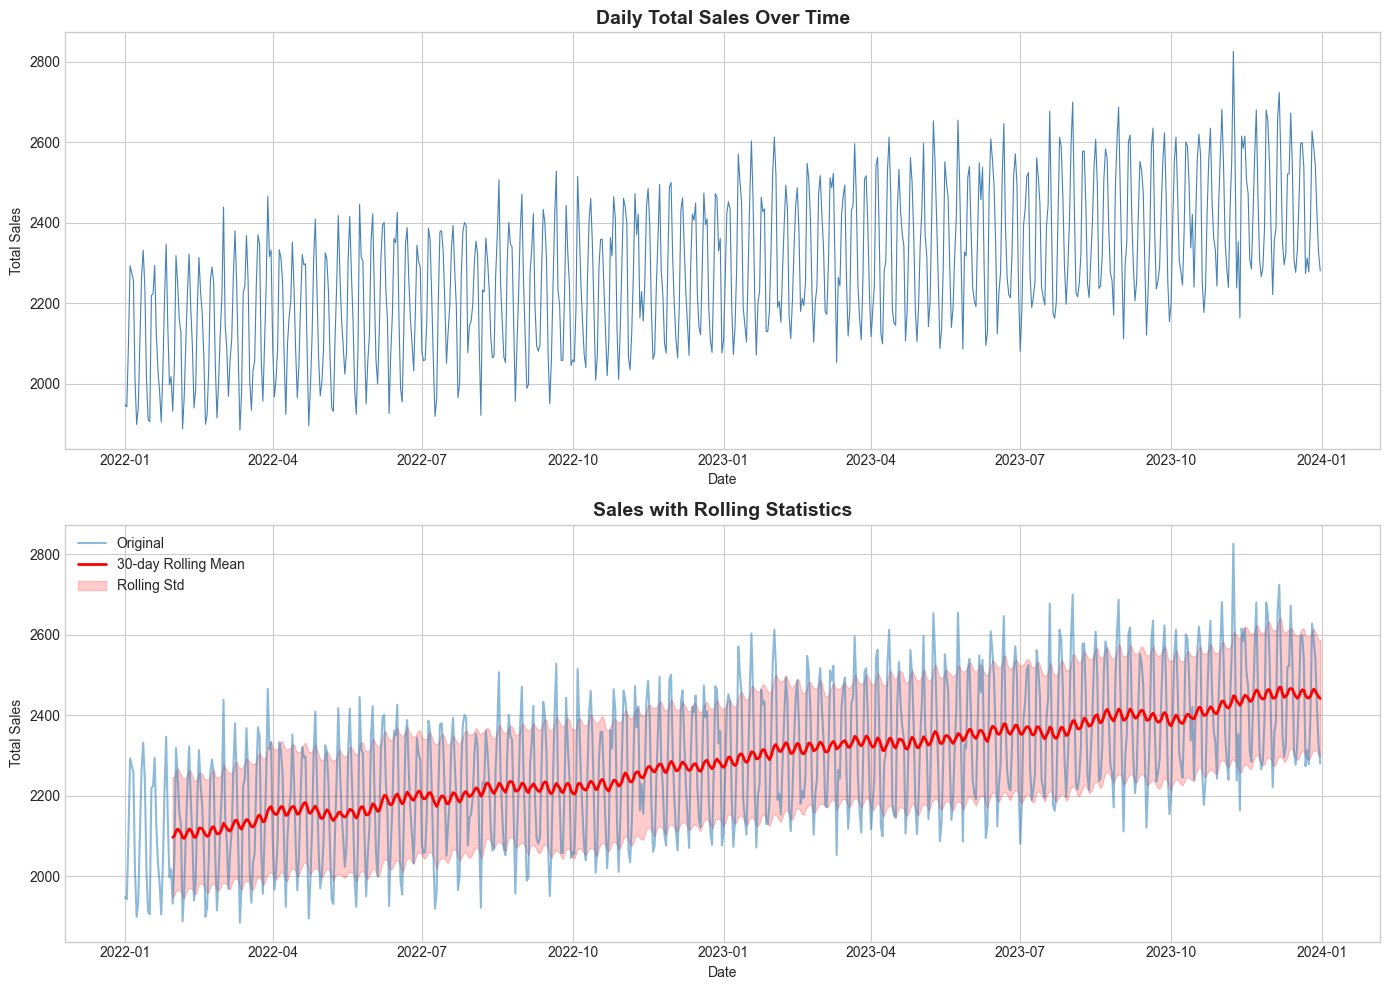

In [6]:
# Visualize the time series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Full time series
axes[0].plot(daily_sales.index, daily_sales['total_sales'], linewidth=0.8, color='steelblue')
axes[0].set_title('Daily Total Sales Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales')

# Rolling mean and std
rolling_mean = daily_sales['total_sales'].rolling(window=30).mean()
rolling_std = daily_sales['total_sales'].rolling(window=30).std()

axes[1].plot(daily_sales.index, daily_sales['total_sales'], label='Original', alpha=0.5)
axes[1].plot(daily_sales.index, rolling_mean, label='30-day Rolling Mean', color='red', linewidth=2)
axes[1].fill_between(daily_sales.index, rolling_mean - rolling_std, rolling_mean + rolling_std, 
                     alpha=0.2, color='red', label='Rolling Std')
axes[1].set_title('Sales with Rolling Statistics', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales')
axes[1].legend()

plt.tight_layout()
plt.savefig('sales_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

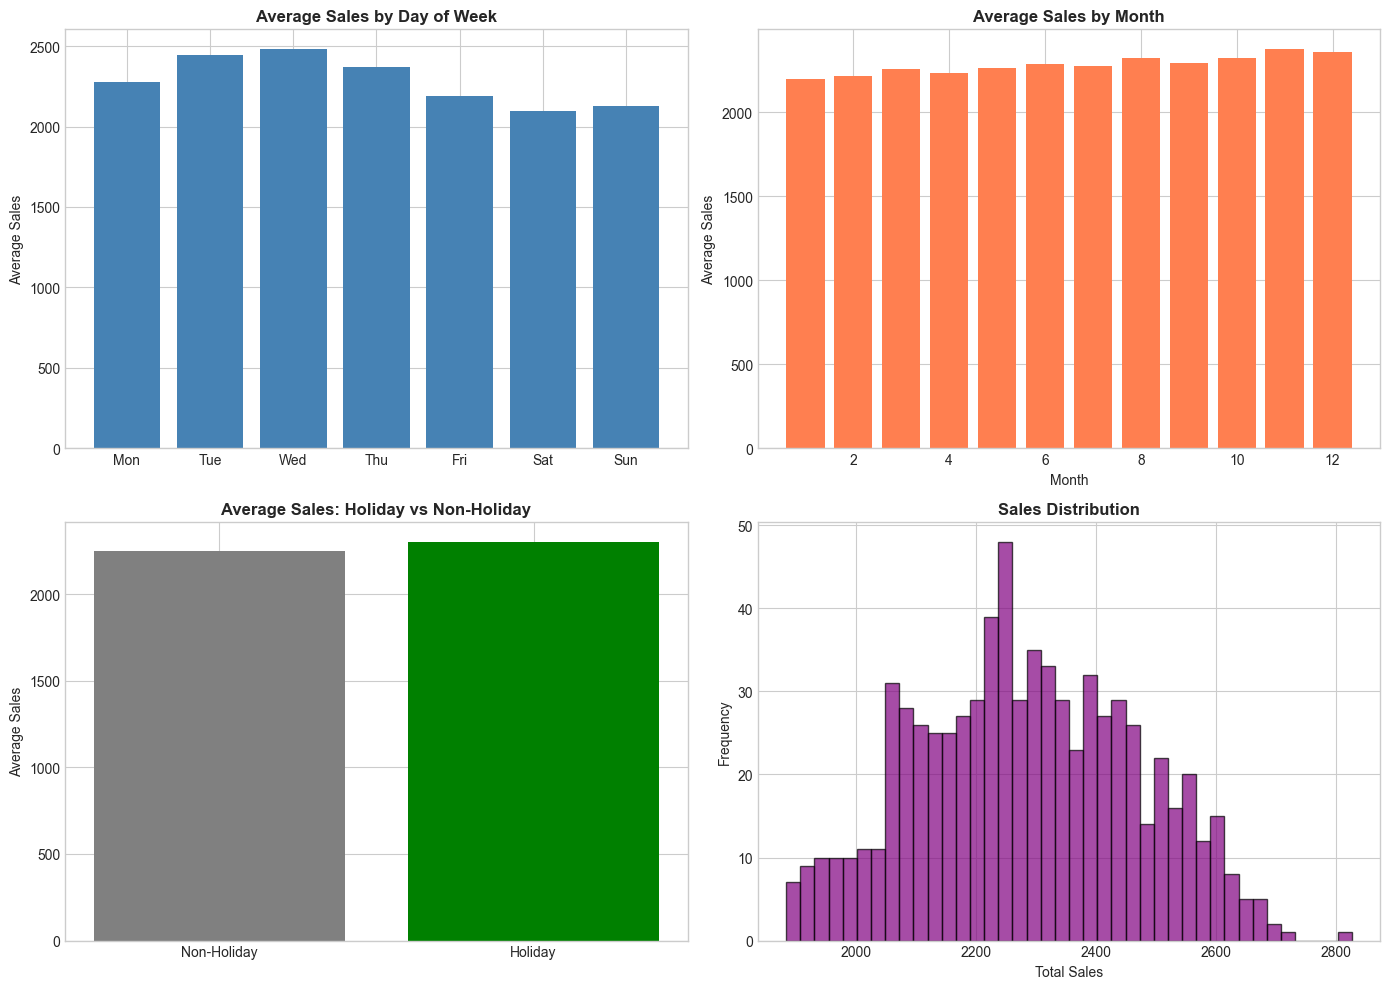

In [7]:
# Analyze sales patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sales by day of week
daily_sales['day_of_week'] = daily_sales.index.dayofweek
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekly_pattern = daily_sales.groupby('day_of_week')['total_sales'].mean()
axes[0, 0].bar(day_names, weekly_pattern.values, color='steelblue')
axes[0, 0].set_title('Average Sales by Day of Week', fontweight='bold')
axes[0, 0].set_ylabel('Average Sales')

# Sales by month
daily_sales['month'] = daily_sales.index.month
monthly_pattern = daily_sales.groupby('month')['total_sales'].mean()
axes[0, 1].bar(range(1, 13), monthly_pattern.values, color='coral')
axes[0, 1].set_title('Average Sales by Month', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Sales')

# Holiday vs Non-Holiday
holiday_sales = daily_sales.groupby('is_holiday')['total_sales'].mean()
axes[1, 0].bar(['Non-Holiday', 'Holiday'], holiday_sales.values, color=['gray', 'green'])
axes[1, 0].set_title('Average Sales: Holiday vs Non-Holiday', fontweight='bold')
axes[1, 0].set_ylabel('Average Sales')

# Sales distribution
axes[1, 1].hist(daily_sales['total_sales'], bins=40, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Sales Distribution', fontweight='bold')
axes[1, 1].set_xlabel('Total Sales')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('sales_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Clean up temp columns
daily_sales = daily_sales.drop(['day_of_week', 'month'], axis=1)

In [8]:
# Check for stationarity using Augmented Dickey-Fuller test
def adf_test(series, title=''):
    """Perform Augmented Dickey-Fuller test for stationarity"""
    result = adfuller(series.dropna())
    print(f'ADF Test Results for {title}')
    print('='*50)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("\n=> Series is STATIONARY (reject null hypothesis)")
        return True
    else:
        print("\n=> Series is NON-STATIONARY (fail to reject null hypothesis)")
        return False

is_stationary = adf_test(daily_sales['total_sales'], 'Total Sales')

ADF Test Results for Total Sales
ADF Statistic: -0.8029
p-value: 0.8183
Critical Values:
   1%: -3.4396
   5%: -2.8656
   10%: -2.5689

=> Series is NON-STATIONARY (fail to reject null hypothesis)



After First Differencing:
ADF Test Results for Differenced Sales
ADF Statistic: -12.6146
p-value: 0.0000
Critical Values:
   1%: -3.4396
   5%: -2.8656
   10%: -2.5689

=> Series is STATIONARY (reject null hypothesis)


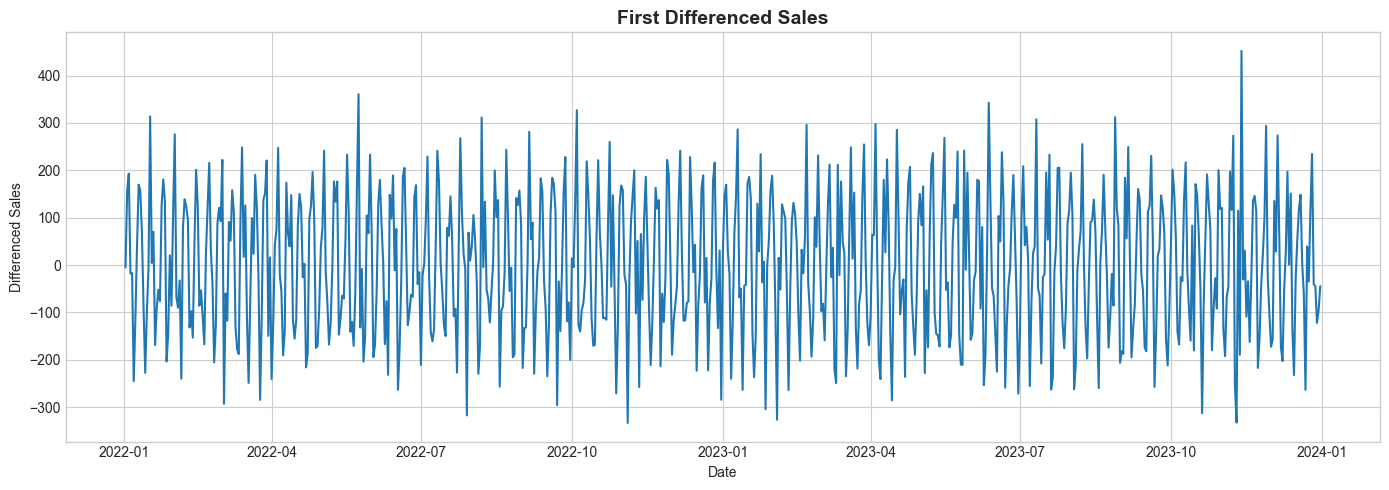

In [9]:
# If not stationary, apply differencing
if not is_stationary:
    daily_sales['sales_diff'] = daily_sales['total_sales'].diff()
    print("\nAfter First Differencing:")
    adf_test(daily_sales['sales_diff'].dropna(), 'Differenced Sales')
    
    # Plot differenced series
    plt.figure(figsize=(14, 5))
    plt.plot(daily_sales['sales_diff'])
    plt.title('First Differenced Sales', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Differenced Sales')
    plt.tight_layout()
    plt.show()

## 4. Train-Test Split

Training set: 2022-01-01 00:00:00 to 2023-08-07 00:00:00 (584 days)
Test set: 2023-08-08 00:00:00 to 2023-12-31 00:00:00 (146 days)


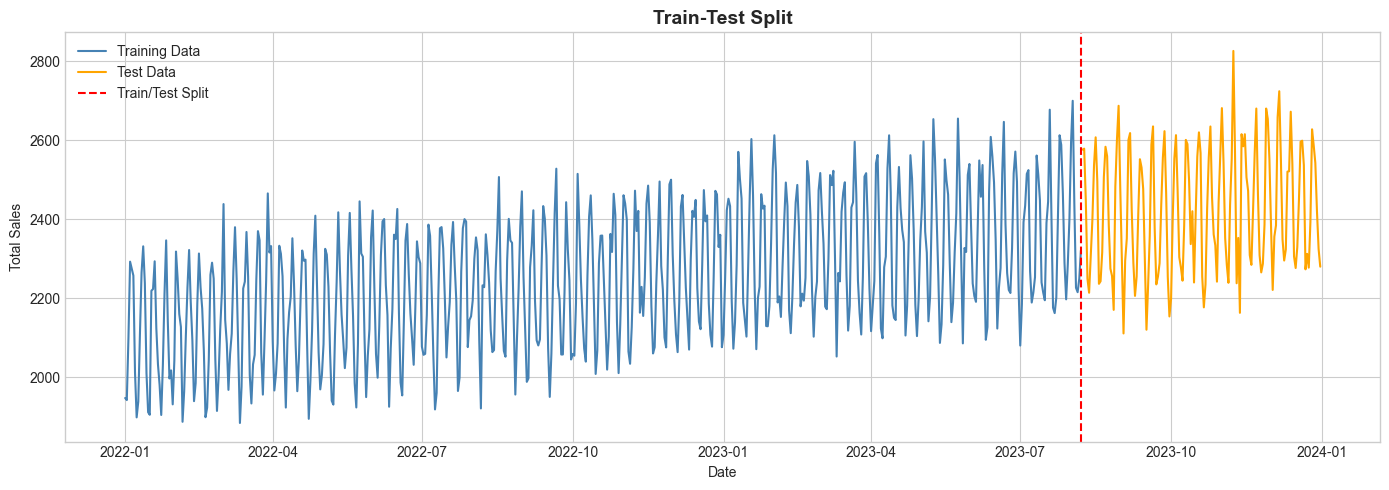

In [10]:
# Split data: 80% train, 20% test
train_size = int(len(daily_sales) * 0.8)
train_data = daily_sales['total_sales'][:train_size]
test_data = daily_sales['total_sales'][train_size:]

print(f"Training set: {train_data.index.min()} to {train_data.index.max()} ({len(train_data)} days)")
print(f"Test set: {test_data.index.min()} to {test_data.index.max()} ({len(test_data)} days)")

# Visualize split
plt.figure(figsize=(14, 5))
plt.plot(train_data.index, train_data, label='Training Data', color='steelblue')
plt.plot(test_data.index, test_data, label='Test Data', color='orange')
plt.axvline(x=train_data.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Train-Test Split', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ACF/PACF Analysis for ARIMA Parameters

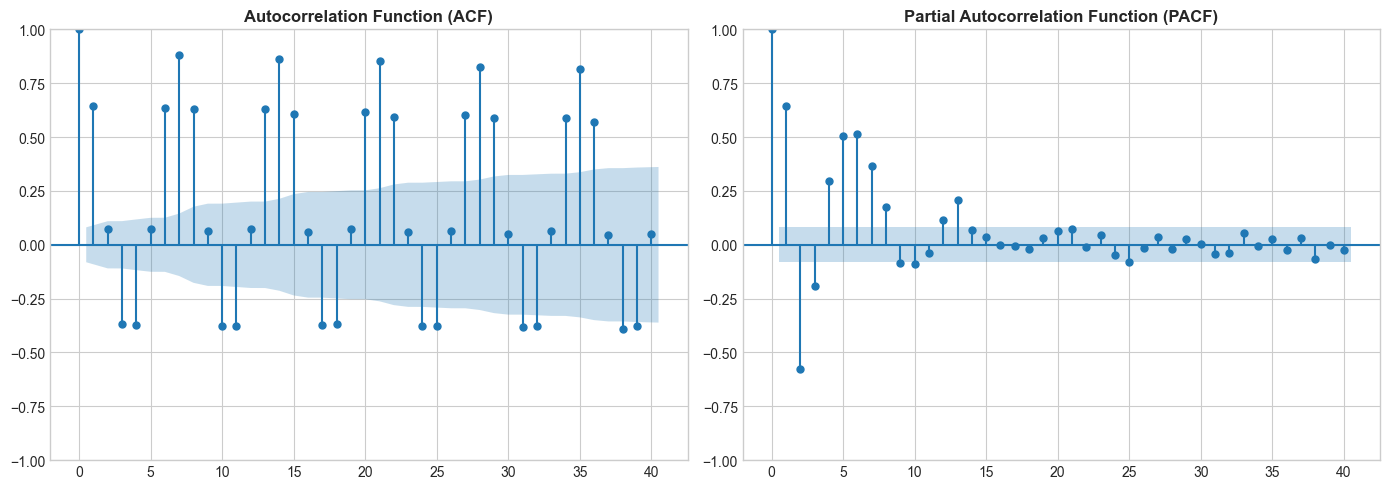


Interpretation:
- ACF helps determine the 'q' parameter (MA order)
- PACF helps determine the 'p' parameter (AR order)
- Look for where the plots cut off or decay significantly


In [11]:
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
plot_acf(train_data.dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')

# PACF plot
plot_pacf(train_data.dropna(), lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- ACF helps determine the 'q' parameter (MA order)")
print("- PACF helps determine the 'p' parameter (AR order)")
print("- Look for where the plots cut off or decay significantly")

## 6. ARIMA Model

In [12]:
# Find optimal ARIMA parameters using AIC
def find_best_arima(series, p_range, d_range, q_range):
    """Find the best ARIMA parameters based on AIC"""
    best_aic = float('inf')
    best_params = None
    results = []
    
    total = len(p_range) * len(d_range) * len(q_range)
    current = 0
    
    for p in p_range:
        for d in d_range:
            for q in q_range:
                current += 1
                try:
                    model = ARIMA(series, order=(p, d, q))
                    fitted = model.fit()
                    aic = fitted.aic
                    results.append({'p': p, 'd': d, 'q': q, 'AIC': aic})
                    
                    if aic < best_aic:
                        best_aic = aic
                        best_params = (p, d, q)
                        print(f"[{current}/{total}] New best: ARIMA{(p,d,q)} with AIC={aic:.2f}")
                except:
                    continue
    
    return best_params, best_aic, pd.DataFrame(results)

# Search for best parameters
print("Searching for optimal ARIMA parameters...")
print("(This may take a few minutes)\n")

best_params, best_aic, results_df = find_best_arima(
    train_data, 
    p_range=range(0, 5), 
    d_range=range(0, 2), 
    q_range=range(0, 5)
)

print(f"\n" + "="*50)
print(f"Best ARIMA Parameters: {best_params}")
print(f"Best AIC: {best_aic:.2f}")
print("="*50)
print("\nTop 10 models by AIC:")
print(results_df.sort_values('AIC').head(10))

Searching for optimal ARIMA parameters...
(This may take a few minutes)

[1/50] New best: ARIMA(0, 0, 0) with AIC=7681.83
[2/50] New best: ARIMA(0, 0, 1) with AIC=7343.82


C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\P

[3/50] New best: ARIMA(0, 0, 2) with AIC=7220.24
[4/50] New best: ARIMA(0, 0, 3) with AIC=7178.26


C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\P

[5/50] New best: ARIMA(0, 0, 4) with AIC=7172.76


...

C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



Best ARIMA Parameters: (3, 1, 3)
Best AIC: 6427.68

Top 10 models by AIC:
    p  d  q          AIC
38  3  1  3  6427.676043
39  3  1  4  6428.682225
48  4  1  3  6433.067909
29  2  1  4  6436.530947
49  4  1  4  6442.062993
34  3  0  4  6446.726712
44  4  0  4  6454.940841
28  2  1  3  6458.939377
43  4  0  3  6496.292421
47  4  1  2  6528.722940


C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
# Fit ARIMA model with best parameters
print(f"\nFitting ARIMA{best_params} model...")
arima_model = ARIMA(train_data, order=best_params)
arima_fitted = arima_model.fit()

print("\nModel Summary:")
print(arima_fitted.summary())

C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



Fitting ARIMA(3, 1, 3) model...



Model Summary:
                               SARIMAX Results                                
Dep. Variable:            total_sales   No. Observations:                  584
Model:                 ARIMA(3, 1, 3)   Log Likelihood               -3206.838
Date:                Wed, 14 Jan 2026   AIC                           6427.676
Time:                        10:30:34   BIC                           6458.253
Sample:                    01-01-2022   HQIC                          6439.594
                         - 08-07-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1654      0.061     19.255      0.000       1.047       1.284
ar.L2         -0.8982      0.075    -11.900      0.000      -1.046      -0.750
ar.L3         -0.0816      0.061    

C:\Users\Siddharth R\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
# Generate ARIMA forecasts
arima_forecast = arima_fitted.forecast(steps=len(test_data))
arima_forecast.index = test_data.index

print(f"ARIMA Forecast generated for {len(arima_forecast)} days")
print(f"\nForecast Statistics:")
print(arima_forecast.describe())

ARIMA Forecast generated for 146 days

Forecast Statistics:
count     146.000000
mean     2386.043095
std       149.030110
min      2182.239985
25%      2220.077669
50%      2381.801205
75%      2546.676689
max      2591.505009
Name: predicted_mean, dtype: float64


## 7. Prophet Model

In [15]:
# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_train = train_data.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_test = test_data.reset_index()
prophet_test.columns = ['ds', 'y']

print("Prophet Training Data:")
print(f"Shape: {prophet_train.shape}")
prophet_train.head()

Prophet Training Data:
Shape: (584, 2)


,ds,y
0,2022-01-01,1947.47
1,2022-01-02,1942.29
2,2022-01-03,2099.73
3,2022-01-04,2292.64
4,2022-01-05,2274.62


In [16]:
# Initialize and train Prophet model
print("Training Prophet model...")

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95,
    changepoint_prior_scale=0.05
)

prophet_model.fit(prophet_train)
print("Prophet model trained successfully!")

10:30:34 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet model...


10:30:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully!


In [17]:
# Generate Prophet forecasts
future_dates = prophet_model.make_future_dataframe(periods=len(test_data))
prophet_predictions = prophet_model.predict(future_dates)

# Extract forecast for test period
prophet_forecast = prophet_predictions[prophet_predictions['ds'].isin(prophet_test['ds'])][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
prophet_forecast = prophet_forecast.set_index('ds')['yhat']

print(f"Prophet Forecast generated for {len(prophet_forecast)} days")
print(f"\nForecast Statistics:")
print(prophet_forecast.describe())

Prophet Forecast generated for 146 days

Forecast Statistics:
count     146.000000
mean     2407.199288
std       144.442708
min      2182.558315
25%      2280.076876
50%      2387.121699
75%      2544.842312
max      2646.387182
Name: yhat, dtype: float64


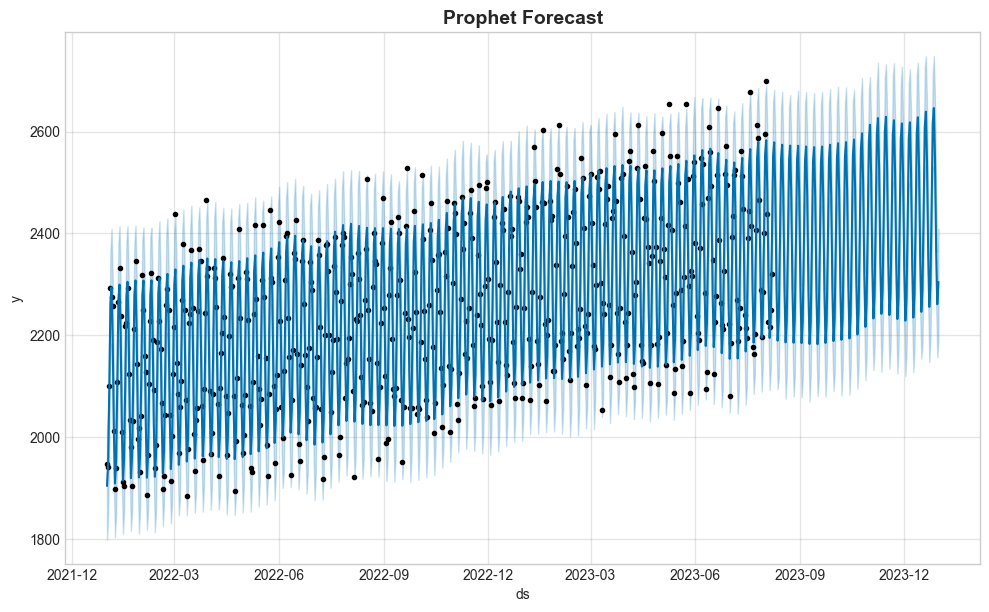

In [18]:
# Plot Prophet forecast
fig1 = prophet_model.plot(prophet_predictions)
plt.title('Prophet Forecast', fontsize=14, fontweight='bold')
plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

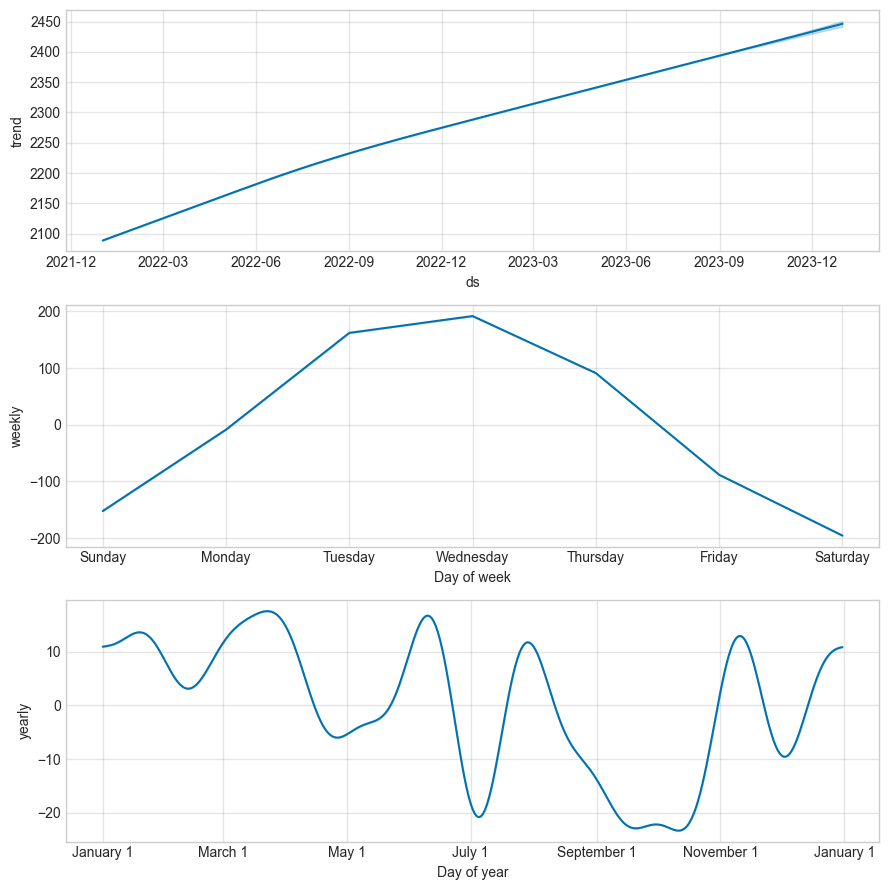

In [19]:
# Plot Prophet components
fig2 = prophet_model.plot_components(prophet_predictions)
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Evaluation

In [20]:
# Define evaluation metrics
def calculate_metrics(actual, predicted, model_name):
    """Calculate evaluation metrics"""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return {
        'Model': model_name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2)
    }

# Calculate metrics for both models
arima_metrics = calculate_metrics(test_data.values, arima_forecast.values, 'ARIMA')
prophet_metrics = calculate_metrics(test_data.values, prophet_forecast.values, 'Prophet')

# Create comparison table
metrics_df = pd.DataFrame([arima_metrics, prophet_metrics])
metrics_df = metrics_df.set_index('Model')

print("="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(metrics_df.to_string())
print("="*60)

# Determine winner
winner = metrics_df['RMSE'].idxmin()
print(f"\n✅ Best Model (lowest RMSE): {winner}")

MODEL EVALUATION RESULTS
           MAE   RMSE  MAPE (%)
Model                          
ARIMA    55.51  72.86      2.29
Prophet  44.95  59.02      1.85

✅ Best Model (lowest RMSE): Prophet


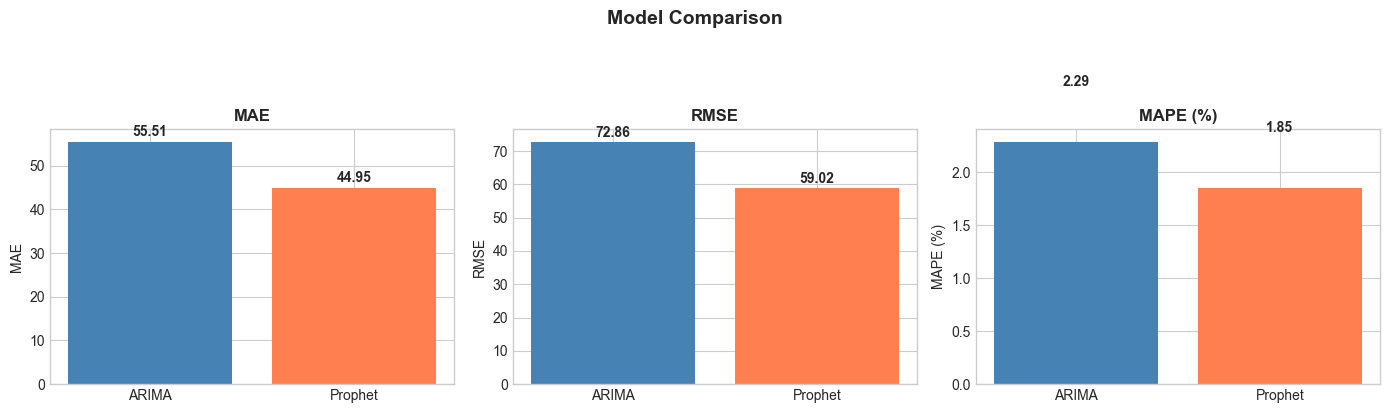

In [21]:
# Visualize evaluation metrics
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics = ['MAE', 'RMSE', 'MAPE (%)']
colors = ['steelblue', 'coral']

for i, metric in enumerate(metrics):
    values = [metrics_df.loc['ARIMA', metric], metrics_df.loc['Prophet', metric]]
    bars = axes[i].bar(['ARIMA', 'Prophet'], values, color=colors)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                    f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

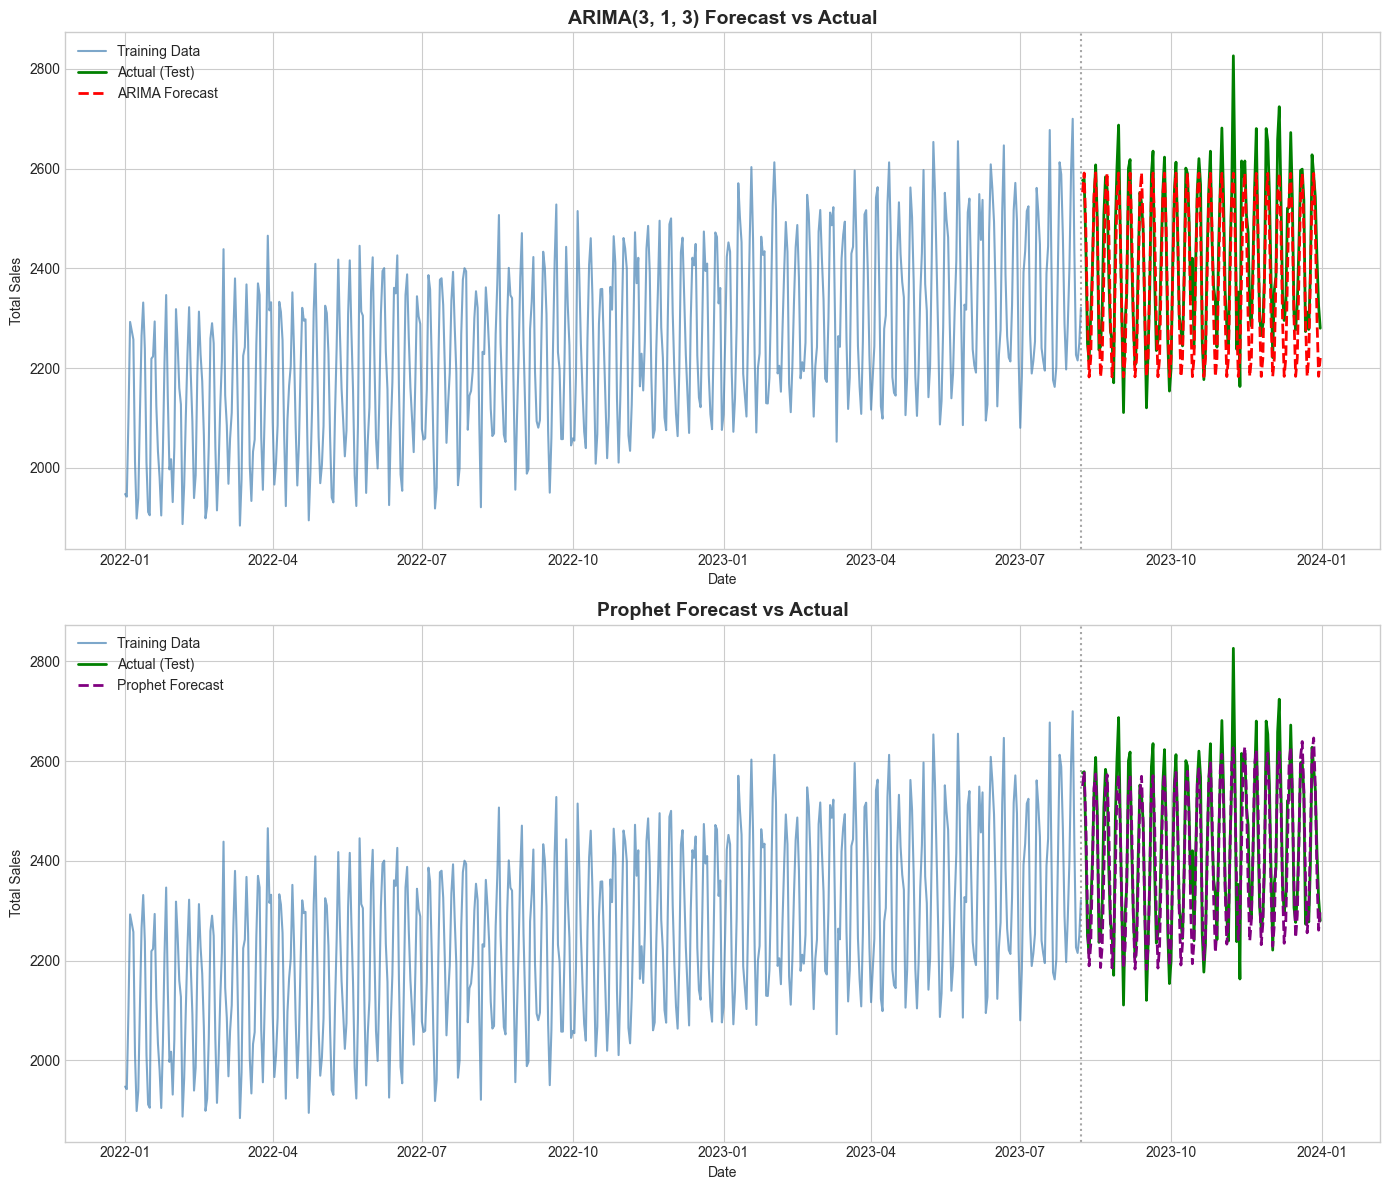

In [22]:
# Visualize forecasts vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# ARIMA forecast
axes[0].plot(train_data.index, train_data, label='Training Data', color='steelblue', alpha=0.7)
axes[0].plot(test_data.index, test_data, label='Actual (Test)', color='green', linewidth=2)
axes[0].plot(arima_forecast.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)
axes[0].axvline(x=train_data.index[-1], color='gray', linestyle=':', alpha=0.7)
axes[0].set_title(f'ARIMA{best_params} Forecast vs Actual', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total Sales')
axes[0].legend(loc='upper left')

# Prophet forecast
axes[1].plot(train_data.index, train_data, label='Training Data', color='steelblue', alpha=0.7)
axes[1].plot(test_data.index, test_data, label='Actual (Test)', color='green', linewidth=2)
axes[1].plot(prophet_forecast.index, prophet_forecast, label='Prophet Forecast', color='purple', linestyle='--', linewidth=2)
axes[1].axvline(x=train_data.index[-1], color='gray', linestyle=':', alpha=0.7)
axes[1].set_title('Prophet Forecast vs Actual', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total Sales')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.savefig('forecasts_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

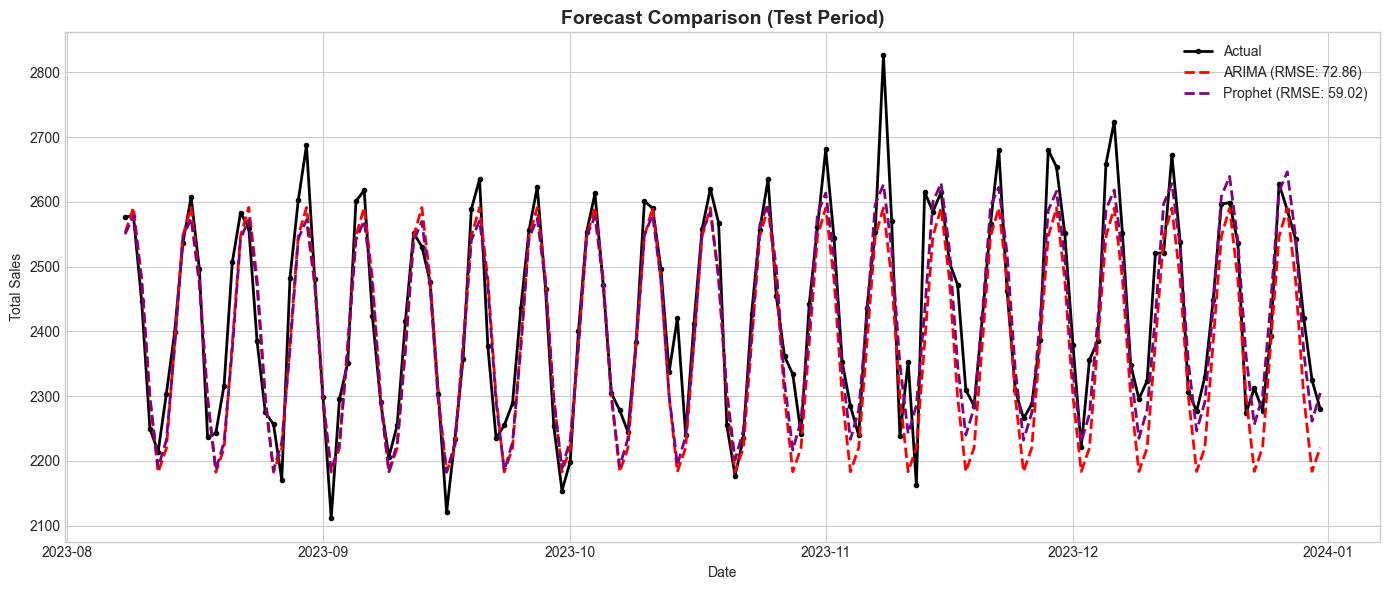

In [23]:
# Zoomed view of forecast period
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test_data.index, test_data, label='Actual', color='black', linewidth=2, marker='o', markersize=3)
ax.plot(arima_forecast.index, arima_forecast, label=f'ARIMA (RMSE: {arima_metrics["RMSE"]})', 
        color='red', linestyle='--', linewidth=2)
ax.plot(prophet_forecast.index, prophet_forecast, label=f'Prophet (RMSE: {prophet_metrics["RMSE"]})', 
        color='purple', linestyle='--', linewidth=2)

ax.set_title('Forecast Comparison (Test Period)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend()

plt.tight_layout()
plt.savefig('forecast_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

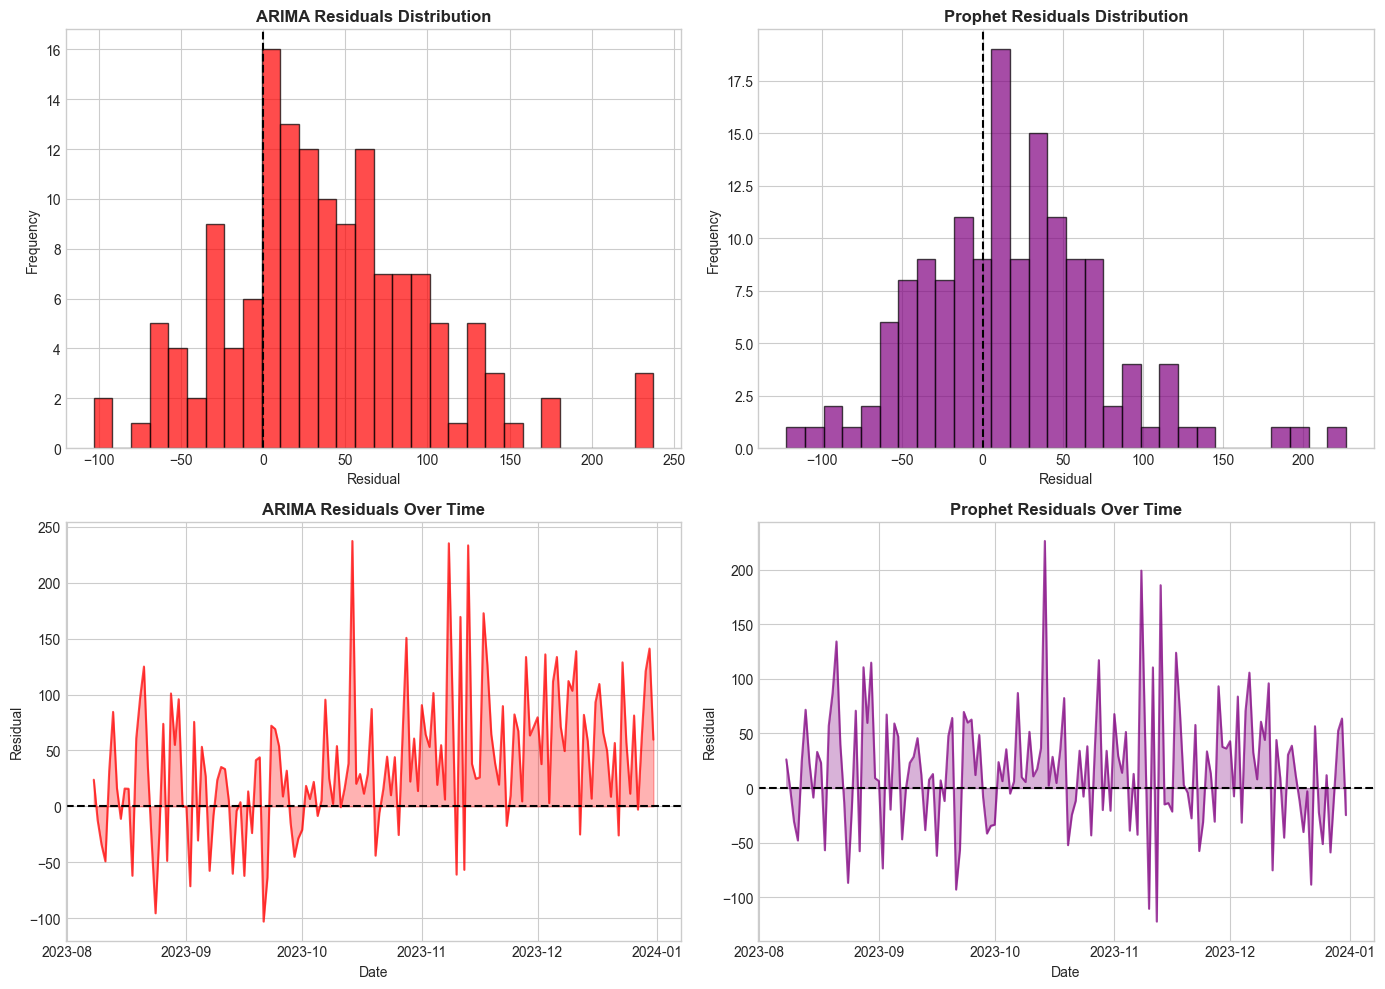

In [24]:
# Residual analysis
arima_residuals = test_data.values - arima_forecast.values
prophet_residuals = test_data.values - prophet_forecast.values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ARIMA residuals distribution
axes[0, 0].hist(arima_residuals, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=0, color='black', linestyle='--')
axes[0, 0].set_title('ARIMA Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Residual')
axes[0, 0].set_ylabel('Frequency')

# Prophet residuals distribution
axes[0, 1].hist(prophet_residuals, bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='black', linestyle='--')
axes[0, 1].set_title('Prophet Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')

# ARIMA residuals over time
axes[1, 0].plot(test_data.index, arima_residuals, color='red', alpha=0.7)
axes[1, 0].axhline(y=0, color='black', linestyle='--')
axes[1, 0].fill_between(test_data.index, arima_residuals, 0, alpha=0.3, color='red')
axes[1, 0].set_title('ARIMA Residuals Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Residual')

# Prophet residuals over time
axes[1, 1].plot(test_data.index, prophet_residuals, color='purple', alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='--')
axes[1, 1].fill_between(test_data.index, prophet_residuals, 0, alpha=0.3, color='purple')
axes[1, 1].set_title('Prophet Residuals Over Time', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Residual')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary and Conclusions

In [25]:
# Final Summary
print("="*70)
print("TIME SERIES FORECASTING - FINAL SUMMARY")
print("="*70)

print("\n📊 DATASET INFORMATION:")
print(f"   - Source: Local file (store_sales.csv)")
print(f"   - Total Records: {len(df):,}")
print(f"   - Number of Stores: {df['store'].nunique()}")
print(f"   - Date Range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   - Training Period: {len(train_data)} days")
print(f"   - Test Period: {len(test_data)} days")

print("\n📈 MODEL PERFORMANCE:")
print(metrics_df.to_string())

print("\n🏆 WINNER:")
print(f"   {winner} model performed better with:")
print(f"   - MAE: {metrics_df.loc[winner, 'MAE']}")
print(f"   - RMSE: {metrics_df.loc[winner, 'RMSE']}")
print(f"   - MAPE: {metrics_df.loc[winner, 'MAPE (%)']}%")

print("\n📁 SAVED VISUALIZATIONS:")
print("   - sales_visualization.png")
print("   - sales_patterns.png")
print("   - train_test_split.png")
print("   - acf_pacf.png")
print("   - prophet_forecast.png")
print("   - prophet_components.png")
print("   - forecasts_comparison.png")
print("   - forecast_zoomed.png")
print("   - metrics_comparison.png")
print("   - residual_analysis.png")

print("\n" + "="*70)
print("END OF ANALYSIS")
print("="*70)

TIME SERIES FORECASTING - FINAL SUMMARY

📊 DATASET INFORMATION:
   - Source: Local file (store_sales.csv)
   - Total Records: 7,300
   - Number of Stores: 10
   - Date Range: 2022-01-01 to 2023-12-31
   - Training Period: 584 days
   - Test Period: 146 days

📈 MODEL PERFORMANCE:
           MAE   RMSE  MAPE (%)
Model                          
ARIMA    55.51  72.86      2.29
Prophet  44.95  59.02      1.85

🏆 WINNER:
   Prophet model performed better with:
   - MAE: 44.95
   - RMSE: 59.02
   - MAPE: 1.85%

📁 SAVED VISUALIZATIONS:
   - sales_visualization.png
   - sales_patterns.png
   - train_test_split.png
   - acf_pacf.png
   - prophet_forecast.png
   - prophet_components.png
   - forecasts_comparison.png
   - forecast_zoomed.png
   - metrics_comparison.png
   - residual_analysis.png

END OF ANALYSIS


In [26]:
# Export results to CSV
results_export = pd.DataFrame({
    'date': test_data.index,
    'actual': test_data.values,
    'arima_forecast': arima_forecast.values,
    'prophet_forecast': prophet_forecast.values,
    'arima_error': arima_residuals,
    'prophet_error': prophet_residuals
})

results_export.to_csv('forecast_results.csv', index=False)
print("Forecast results exported to: forecast_results.csv")

Forecast results exported to: forecast_results.csv
